# Disaster Tweets Prediction


In [8]:
!wget https://raw.githubusercontent.com/umerkang66/ai-ml-dl/refs/heads/master/tensorflow-bootcamp/03-computer-vision-tf/helper_functions.py

--2026-08-22 18:31:34--  https://raw.githubusercontent.com/umerkang66/ai-ml-dl/refs/heads/master/tensorflow-bootcamp/03-computer-vision-tf/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10836 (11K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.58K  --.-KB/s    in 0s      

2026-08-22 18:31:34 (102 MB/s) - ‘helper_functions.py’ saved [10836/10836]



In [9]:
from helper_functions import (
    unzip_data,
    plot_loss_curves,
    compare_historys,
    make_confusion_matrix,
)

## Kaggle Intro to NLP Dataset


In [10]:
!wget https://storage.googleapis.com/ztm_tf_course/nlp_getting_started.zip

--2026-08-22 18:31:39--  https://storage.googleapis.com/ztm_tf_course/nlp_getting_started.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 104.154.124.27, 34.3.0.27, 34.153.3.27, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|104.154.124.27|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 607343 (593K) [application/zip]
Saving to: ‘nlp_getting_started.zip’

nlp_getting_started 100%[===================>] 593.11K  --.-KB/s    in 0.003s  

2026-08-22 18:31:39 (177 MB/s) - ‘nlp_getting_started.zip’ saved [607343/607343]



In [11]:
unzip_data("nlp_getting_started.zip")

## Read the Data


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split

train_df = pd.read_csv("train.csv")[["text", "target"]]

train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42)

test_df = pd.read_csv("test.csv")[["text"]]

In [13]:
train_df.head()

,text,target
4620,'McFadden Reportedly to Test Hamstring Thursda...,0
2858,w--=-=-=-[ NEMA warns Nigerians to prepare for...,1
3098,When I was cooking earlier I got electrocuted ...,0
3751,I'm On Fire. http://t.co/WATsmxYTVa,0
5285,More than 40 families affected by the fatal ou...,1


## Shuffle the training data


In [14]:
train_df_shuffled = train_df.sample(frac=1, random_state=42)

In [15]:
train_df_shuffled.head()

,text,target
3347,78 passengers evacuated safely after Green Lin...,1
6177,@KIRO7Seattle Just saw a Bomb Squad car headin...,1
6970,@Kamunt Holy crap it's been forever since I sa...,0
1497,Learning from the Legacy of a Catastrophic Eru...,1
3453,luke + microphone = exploded ovaries,0


In [16]:
val_df.head()

,text,target
2644,So you have a new weapon that can cause un-ima...,1
2227,The f$&amp;@ing things I do for #GISHWHES Just...,0
5448,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe...,1
132,Aftershock back to school kick off was great. ...,0
6845,in response to trauma Children of Addicts deve...,0


In [17]:
test_df.head()

,text
0,Just happened a terrible car crash
1,"Heard about #earthquake is different cities, s..."
2,"there is a forest fire at spot pond, geese are..."
3,Apocalypse lighting. #Spokane #wildfires
4,Typhoon Soudelor kills 28 in China and Taiwan


In [18]:
train_df.target.value_counts()

,count
target,
0,3916
1,2935


In [19]:
len(train_df), len(test_df)

(6851, 3263)

## Let's visualize some random samples


In [20]:
import random

random_index = random.randint(0, len(train_df) - 1)

for _, row in train_df.iloc[random_index : random_index + 5].iterrows():
    text, target = row

    print(
        f"Target: {target}", "(real disaster)" if target > 0 else "(not real disaster)"
    )
    print(f"Text: {text}\n")

Target: 0 (not real disaster)
Text: I wrecked my stomach help

Target: 1 (real disaster)
Text: @guardian Has Japan ever truly come to terms with devastation and mass murder of millions of Chinese and others with traditional weapons?

Target: 0 (not real disaster)
Text: New post from @SeismicSoftware: 3 Major Challenges of Channel Sales Enablement http://t.co/kWMRCEkVTF

Target: 1 (real disaster)
Text: Russia destroys food while people go hungry.  We're not the only ones with an insane government.
http://t.co/ZonNqGsxYw

Target: 1 (real disaster)
Text: Civilian casualties rise as Afghan war intensifies in 2015-- http://t.co/NnylXhInPx



## Converting text into numbers


In [21]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

In [22]:
average_max_length = round(
    sum([len(i.split()) for i in train_df["text"]]) / len(train_df)
)

In [23]:
# we have already defaulted this, but here we are setting again
max_length = average_max_length  # how many words from a tweet our model will see


text_vectorizer = TextVectorization(
    max_tokens=10000,  # None = no limit on the number of tokens vocab can have
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    ngrams=None,  # treat each word as a token
    output_mode="int",  # convert tokens into integers
    output_sequence_length=max_length,  # pad all outputs to be max_length tokens long
    pad_to_max_tokens=True,
)

In [24]:
# fit the text vectorizer to the training text

text_vectorizer.adapt(train_df["text"])

In [25]:
# create a sample text and pass it through our text vectorizer instance

sample_text = "There's a flood in my street!"

text_vectorizer([sample_text])

<tf.Tensor: shape=(1, 15), dtype=int64, numpy=
array([[282,   3, 206,   4,  13, 674,   0,   0,   0,   0,   0,   0,   0,
          0,   0]])>

In [26]:
# choose a random text from the training dataset and pass it through the text vectorizer

import random

random_sentence = random.choice(train_df["text"])

print(f"Original text:\n{random_sentence} \n")
print(f"Vectorized version:\n{text_vectorizer([random_sentence])}")

Original text:
Wait What??? http://t.co/uAVFRtlfs4 http://t.co/85G1pCcCXG 

Vectorized version:
[[701  54   1   1   0   0   0   0   0   0   0   0   0   0   0]]


In [27]:
# get the unique words in the vocabulary of our text vectorizer instance

words_in_vocab = text_vectorizer.get_vocabulary()

print("Top 5 words in vocab: ", words_in_vocab[:5])
print("Bottom 5 words in vocab: ", words_in_vocab[-5:])
print("Number of words in vocab: ", len(words_in_vocab))

Top 5 words in vocab:  ['', '[UNK]', np.str_('the'), np.str_('a'), np.str_('in')]
Bottom 5 words in vocab:  [np.str_('pakthey'), np.str_('pakistan\x89Ûªs'), np.str_('pakistans'), np.str_('pajamas'), np.str_('paints')]
Number of words in vocab:  10000


In [28]:
from tensorflow.keras.layers import Embedding

embedding = Embedding(
    input_dim=len(
        words_in_vocab
    ),  # total vocabulary size (i.e. number of unique tokens in the text)
    output_dim=128,  # set size of embedding vector
    input_length=max_length,  # how long is each input
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [29]:
random_sentence = random.choice(train_df["text"])


print(f"Original text:\n{random_sentence} \n")
print(f"Vectorized version:\n{text_vectorizer([random_sentence])}")

sample_embed = embedding(text_vectorizer([random_sentence]))


print(f"Embedded version:\n{sample_embed}")
print(f"Embedded version shape:\n{sample_embed.shape}")

Original text:
Rly tragedy in MP: Some live to recount horror: ÛÏWhen I saw coaches of my train plunging into water I called ... http://t.co/xtlJz7BjgL 

Vectorized version:
[[1053  454    4  649   77  186    5 1107  629 1223    8  408  912    6
    13]]
Embedded version:
[[[-0.02999904  0.03922607  0.02867058 ... -0.0010008   0.03068138
    0.00083695]
  [ 0.04814216 -0.02820704 -0.02300876 ... -0.0183442  -0.00329078
   -0.04661554]
  [ 0.01644968 -0.01243833  0.01493836 ... -0.02410254 -0.0458496
    0.00647331]
  ...
  [-0.01053787 -0.00485963  0.01511684 ...  0.00591884 -0.01192253
   -0.00628934]
  [-0.04505781  0.00745279 -0.00521597 ... -0.01791676 -0.04806191
    0.02212012]
  [ 0.03069973 -0.0243255   0.03409637 ...  0.00569665  0.01125861
   -0.01686925]]]
Embedded version shape:
(1, 15, 128)


In [30]:
sample_embed[0][0], sample_embed[0][0].shape

(<tf.Tensor: shape=(128,), dtype=float32, numpy=
 array([-0.02999904,  0.03922607,  0.02867058,  0.03144077, -0.00411719,
        -0.02096649, -0.02666243, -0.01448634,  0.00289339, -0.03485596,
        -0.00202154,  0.03286928,  0.03087183,  0.02032616,  0.02947812,
         0.01360898,  0.04488089, -0.03321888,  0.0463688 , -0.04577601,
        -0.03422161, -0.03824145, -0.04962813,  0.00534236, -0.04699305,
        -0.04249076, -0.01194198,  0.00879748,  0.04108224, -0.01789958,
         0.02595353, -0.00020925,  0.03199916,  0.0213396 , -0.0399578 ,
        -0.01562389, -0.03201054,  0.01643345,  0.0394221 , -0.0053087 ,
        -0.04701269,  0.01147661,  0.03828973, -0.04522936, -0.04558178,
        -0.04816477, -0.02241447, -0.01781293, -0.0449481 ,  0.04633993,
         0.01013602,  0.03673508, -0.00620735, -0.01400544,  0.00628734,
        -0.03584025,  0.00429362, -0.04862949, -0.00891904, -0.04133589,
        -0.0489459 ,  0.04018463, -0.0227748 ,  0.00075225, -0.03861938,
  

## Experiment Models

- Model 0: Naive Bayes (Baseline)
- Model 1: Feed Forward Neural Network (dense model)
- Model 2: LSTM model (RNN)
- Model 3: GRU model (RNN)
- Model 4: Bidirectional-LSTM (RNN)
- Model 5: 1D Convolutional Neural Network (CNN)
- Model 6: Pretrained Transformer Feature Extractor (Hugging Face DistilBERT - Transfer Learning)


## MODEL_0: BaseLine Naive Bayes


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# Create tokenization and modelling pipeline
model_0 = Pipeline(
    [
        ("tfidf", TfidfVectorizer()),  # convert words to numbers using tfidf
        ("clf", MultinomialNB()),  # model the text
    ]
)

# Fit the pipeline to the training data
model_0.fit(train_df["text"], train_df["target"])

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', MultinomialNB())])

In [32]:
# Evaluate baseline model
baseline_score = model_0.score(val_df["text"], val_df["target"])
print(f"Our baseline model achieves an accuracy of: {baseline_score * 100:.2f}%")

Our baseline model achieves an accuracy of: 77.82%


In [33]:
# Make predictions
baseline_preds = model_0.predict(val_df["text"])

In [34]:
# Calculate baseline results
from helper_functions import calculate_results

baseline_results = calculate_results(y_true=val_df["target"], y_pred=baseline_preds)
baseline_results

{'accuracy': 77.82152230971128,
 'precision': 0.792992256322435,
 'recall': 0.7782152230971129,
 'f1': 0.7703527809038112}

## MODEL_1: FFNN


In [35]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D

In [36]:
inputs = tf.keras.layers.Input(
    shape=(1,), dtype=tf.string
)  # inputs are 1 dimenional strings (i.e. sentences)

x = text_vectorizer(inputs)  # turn the input text into numbers
x = embedding(x)  # create an embedding of the numberized inputs

x = GlobalAveragePooling1D()(x)

outputs = Dense(1, activation="sigmoid")(x)


model_1 = tf.keras.Model(inputs, outputs, name="model_1_dense")

In [37]:
model_1.summary()

Model: "model_1_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 15)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,129 (4.88 MB)

 Trainable params: 1,280,129 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model_1.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"],
)

model_1_history = model_1.fit(
    train_df["text"].to_numpy(),
    train_df["target"].to_numpy(),
    epochs=5,
    validation_data=(val_df["text"].to_numpy(), val_df["target"].to_numpy()),
)

Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6998 - loss: 0.6047 - val_accuracy: 0.7730 - val_loss: 0.5383
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8196 - loss: 0.4393 - val_accuracy: 0.7940 - val_loss: 0.4888
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8640 - loss: 0.3477 - val_accuracy: 0.7861 - val_loss: 0.4774
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8894 - loss: 0.2842 - val_accuracy: 0.7940 - val_loss: 0.4827
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9110 - loss: 0.2375 - val_accuracy: 0.7808 - val_loss: 0.5071


In [39]:
model1_pred_probs = model_1.predict(val_df["text"].to_numpy())

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [40]:
model1_preds = tf.squeeze(tf.round(model1_pred_probs))

model1_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 0., 0., 0., 1., 0., 0., 0., 0., 1.], dtype=float32)>

In [41]:
model_1_results = calculate_results(y_true=val_df["target"], y_pred=model1_preds)

model_1_results

{'accuracy': 78.08398950131233,
 'precision': 0.7834394122894525,
 'recall': 0.7808398950131233,
 'f1': 0.7775550514529078}

## MODEL2: LSTM


In [42]:
from tensorflow.keras.layers import LSTM

inputs = tf.keras.layers.Input(shape=(1,), dtype=tf.string)

x = text_vectorizer(inputs)
x = embedding(x)
x = LSTM(64, return_sequences=True)(x)
x = LSTM(64)(x)
outputs = Dense(1, activation="sigmoid")(x)

model_2 = tf.keras.Model(inputs, outputs, name="model_2_LSTM")

model_2.summary()

Model: "model_2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 15)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 15, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,362,497 (5.20 MB)

 Trainable params: 1,362,497 (5.20 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# Compile model
model_2.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"],
)

# Fit model
model_2_history = model_2.fit(
    train_df["text"].to_numpy(),
    train_df["target"].to_numpy(),
    epochs=5,
    validation_data=(val_df["text"].to_numpy(), val_df["target"].to_numpy()),
)

Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9187 - loss: 0.2203 - val_accuracy: 0.7756 - val_loss: 0.6162
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9388 - loss: 0.1581 - val_accuracy: 0.7690 - val_loss: 0.6516
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9531 - loss: 0.1272 - val_accuracy: 0.7690 - val_loss: 0.7971
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9596 - loss: 0.1055 - val_accuracy: 0.7598 - val_loss: 0.9746
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9653 - loss: 0.0875 - val_accuracy: 0.7585 - val_loss: 1.0239


In [44]:
# Make predictions on the validation set
model_2_pred_probs = model_2.predict(val_df["text"].to_numpy())

# Convert prediction probabilities to 0 or 1 binary classes
model_2_preds = tf.squeeze(tf.round(model_2_pred_probs))

# Calculate evaluation metrics (Accuracy, Precision,Recall, F1-score)
from helper_functions import calculate_results

model_2_results = calculate_results(
    y_true=val_df["target"].to_numpy(), y_pred=model_2_preds
)
model_2_results

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


{'accuracy': 75.8530183727034,
 'precision': 0.7583779582360232,
 'recall': 0.7585301837270341,
 'f1': 0.7563028552860761}

## MODEL3: GRU


In [45]:
from tensorflow.keras.layers import GRU

inputs = tf.keras.layers.Input(shape=(1,), dtype=tf.string)

x = text_vectorizer(inputs)
x = embedding(x)
x = GRU(64, return_sequences=True)(x)
x = GRU(64)(x)
outputs = Dense(1, activation="sigmoid")(x)

model_3 = tf.keras.Model(inputs, outputs, name="model_3_GRU")

model_3.summary()

Model: "model_3_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 15)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 15, 64)         │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,342,273 (5.12 MB)

 Trainable params: 1,342,273 (5.12 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
# Compile model
model_3.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"],
)

# Fit model
model_3_history = model_3.fit(
    train_df["text"].to_numpy(),
    train_df["target"].to_numpy(),
    epochs=5,
    validation_data=(val_df["text"].to_numpy(), val_df["target"].to_numpy()),
)

Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9498 - loss: 0.1382 - val_accuracy: 0.7454 - val_loss: 0.7554
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9680 - loss: 0.0876 - val_accuracy: 0.7533 - val_loss: 0.6185
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9718 - loss: 0.0750 - val_accuracy: 0.7402 - val_loss: 1.1903
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9726 - loss: 0.0669 - val_accuracy: 0.7625 - val_loss: 1.0324
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9755 - loss: 0.0564 - val_accuracy: 0.7402 - val_loss: 1.0433


In [47]:
# Make predictions on the validation set
model_3_pred_probs = model_3.predict(val_df["text"].to_numpy())

# Convert prediction probabilities to 0 or 1 binary classes
model_3_preds = tf.squeeze(tf.round(model_3_pred_probs))

# Calculate evaluation metrics (Accuracy, Precision,Recall, F1-score)
from helper_functions import calculate_results

model_3_results = calculate_results(
    y_true=val_df["target"].to_numpy(), y_pred=model_3_preds
)
model_3_results

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


{'accuracy': 74.01574803149606,
 'precision': 0.739179765071229,
 'recall': 0.7401574803149606,
 'f1': 0.7391520110050971}

## MODEL4: Bidirectional LSTM


In [48]:
from tensorflow.keras.layers import Bidirectional, LSTM

inputs = tf.keras.layers.Input(shape=(1,), dtype=tf.string)

x = text_vectorizer(inputs)
x = embedding(x)
# x = Bidirectional(LSTM(64, return_sequences=True))(x) # Stacking bidirectional RNNs
x = Bidirectional(LSTM(64))(x)
outputs = Dense(1, activation="sigmoid")(x)

model_4 = tf.keras.Model(inputs, outputs, name="model_4_Bidirectional_LSTM")

model_4.summary()

Model: "model_4_Bidirectional_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 15)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,378,945 (5.26 MB)

 Trainable params: 1,378,945 (5.26 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# Compile model
model_4.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"],
)

# Fit model
model_4_history = model_4.fit(
    train_df["text"].to_numpy(),
    train_df["target"].to_numpy(),
    epochs=5,
    validation_data=(val_df["text"].to_numpy(), val_df["target"].to_numpy()),
)

Epoch 1/5


215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9645 - loss: 0.1095 - val_accuracy: 0.7441 - val_loss: 1.1710
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9784 - loss: 0.0513 - val_accuracy: 0.7598 - val_loss: 1.2246
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9778 - loss: 0.0474 - val_accuracy: 0.7375 - val_loss: 1.3974
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9756 - loss: 0.0477 - val_accuracy: 0.7375 - val_loss: 1.4763
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9810 - loss: 0.0387 - val_accuracy: 0.7480 - val_loss: 1.4737


In [50]:
# Make predictions on the validation set
model_4_pred_probs = model_4.predict(val_df["text"].to_numpy())

# Convert prediction probabilities to 0 or 1 binary classes
model_4_preds = tf.squeeze(tf.round(model_4_pred_probs))

# Calculate evaluation metrics (Accuracy, Precision,Recall, F1-score)
from helper_functions import calculate_results

model_4_results = calculate_results(
    y_true=val_df["target"].to_numpy(), y_pred=model_4_preds
)
model_4_results

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


{'accuracy': 74.80314960629921,
 'precision': 0.7472497045660605,
 'recall': 0.7480314960629921,
 'f1': 0.7462927993729291}

## MODEL5: Conv1D (1D Convolutional Neural Network)


In [51]:
from tensorflow.keras.layers import Conv1D, GlobalMaxPool1D

inputs = tf.keras.layers.Input(shape=(1,), dtype=tf.string)

x = text_vectorizer(inputs)
x = embedding(x)
x = Conv1D(filters=64, kernel_size=5, strides=1, activation="relu", padding="valid")(x)
x = GlobalMaxPool1D()(x)

# 2 dense layers for classification
x = Dense(64, activation="relu")(x)  # Optional dense layer
outputs = Dense(1, activation="sigmoid")(x)

model_5 = tf.keras.Model(inputs, outputs, name="model_5_Conv1D")

model_5.summary()

Model: "model_5_Conv1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 15)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 11, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,325,249 (5.06 MB)

 Trainable params: 1,325,249 (5.06 MB)

 Non-trainable params: 0 (0.00 B)

In [52]:
# Compile model
model_5.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"],
)

# Fit model
model_5_history = model_5.fit(
    train_df["text"].to_numpy(),
    train_df["target"].to_numpy(),
    epochs=5,
    validation_data=(val_df["text"].to_numpy(), val_df["target"].to_numpy()),
)

Epoch 1/5


215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9575 - loss: 0.1209 - val_accuracy: 0.7349 - val_loss: 1.0752
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9739 - loss: 0.0664 - val_accuracy: 0.7375 - val_loss: 1.2662
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9790 - loss: 0.0468 - val_accuracy: 0.7297 - val_loss: 1.6024
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9803 - loss: 0.0392 - val_accuracy: 0.7402 - val_loss: 1.7066
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9826 - loss: 0.0340 - val_accuracy: 0.7336 - val_loss: 1.8709


In [53]:
# Make predictions on the validation set
model_5_pred_probs = model_5.predict(val_df["text"].to_numpy())

# Convert prediction probabilities to 0 or 1 binary classes
model_5_preds = tf.squeeze(tf.round(model_5_pred_probs))

# Calculate evaluation metrics (Accuracy, Precision,Recall, F1-score)
from helper_functions import calculate_results

model_5_results = calculate_results(
    y_true=val_df["target"].to_numpy(), y_pred=model_5_preds
)
model_5_results

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


{'accuracy': 73.35958005249343,
 'precision': 0.7336811332865115,
 'recall': 0.7335958005249343,
 'f1': 0.7336371992006524}

## MODEL6: Transfer Learning (Pretrained Transformer - Hugging Face DistilBERT with PyTorch)

Now we'll use a modern pretrained Transformer model: **DistilBERT** (`distilbert-base-uncased`) from Hugging Face using **PyTorch (`torch`)**.
DistilBERT is a lightweight, high-performance Transformer that retains 97% of BERT's language understanding capabilities while being 40% smaller and 60% faster. We freeze the pretrained transformer backbone to extract rich contextual embeddings (CLS token representation) and train a classification head on top.


In [54]:
# Import PyTorch and Hugging Face Transformers
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModel, AutoTokenizer

# Device configuration (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load pretrained DistilBERT tokenizer
checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)


# Helper function to tokenize text data into PyTorch tensors
def tokenize_dataset(texts, max_length=128):
    return tokenizer(
        list(texts),
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )


# Tokenize train, validation, and test text datasets
train_encodings = tokenize_dataset(train_df["text"])
val_encodings = tokenize_dataset(val_df["text"])
test_encodings = tokenize_dataset(test_df["text"])

# Create PyTorch DataLoaders
train_dataset = TensorDataset(
    train_encodings["input_ids"],
    train_encodings["attention_mask"],
    torch.tensor(train_df["target"].values, dtype=torch.float32),
)
val_dataset = TensorDataset(
    val_encodings["input_ids"],
    val_encodings["attention_mask"],
    torch.tensor(val_df["target"].values, dtype=torch.float32),
)
test_dataset = TensorDataset(
    test_encodings["input_ids"],
    test_encodings["attention_mask"],
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Using device: cuda


In [55]:
# Inspect a sample tokenized sentence
sample_sentence = "There's a flood in my street!"
sample_tokenized = tokenizer(
    sample_sentence,
    padding="max_length",
    truncation=True,
    max_length=15,
    return_tensors="pt",
)

print(f"Original text:\n{sample_sentence}\n")
print(f"Tokenized IDs (first 15 tokens):\n{sample_tokenized['input_ids'][0]}\n")
print(
    f"Decoded tokens:\n{tokenizer.convert_ids_to_tokens(sample_tokenized['input_ids'][0])}\n"
)

Original text:
There's a flood in my street!

Tokenized IDs (first 15 tokens):
tensor([ 101, 2045, 1005, 1055, 1037, 7186, 1999, 2026, 2395,  999,  102,    0,
           0,    0,    0])

Decoded tokens:
['[CLS]', 'there', "'", 's', 'a', 'flood', 'in', 'my', 'street', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']



In [56]:
# Build Model 6 using PyTorch: Frozen DistilBERT + Dense Head
class DistilBERTClassifier(nn.Module):
    def __init__(self, checkpoint="distilbert-base-uncased"):
        super().__init__()
        # Load pretrained DistilBERT backbone
        self.distilbert = AutoModel.from_pretrained(checkpoint)

        # Freeze pretrained weights for feature extraction transfer learning
        for param in self.distilbert.parameters():
            param.requires_grad = False

        # Classification Head: Dense(64, ReLU) -> Dense(1)
        self.dense = nn.Linear(768, 64)
        self.relu = nn.ReLU()
        self.out = nn.Linear(64, 1)

    def forward(self, input_ids, attention_mask):
        # Extract contextual representations from DistilBERT
        transformer_output = self.distilbert(
            input_ids=input_ids, attention_mask=attention_mask
        )
        # Extract [CLS] token representation (shape: batch_size, 768)
        cls_representation = transformer_output.last_hidden_state[:, 0, :]
        x = self.relu(self.dense(cls_representation))
        logits = self.out(x)
        return logits.squeeze(-1)


model_6 = DistilBERTClassifier(checkpoint).to(device)
print(model_6)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERTClassifier(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (li

In [57]:
# Loss and Optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_6.parameters()), lr=1e-3
)

epochs = 5
for epoch in range(epochs):
    model_6.train()
    total_train_loss = 0.0

    for input_ids, attention_mask, targets in train_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        logits = model_6(input_ids, attention_mask)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{epochs} | Train Loss: {avg_train_loss:.4f}")

Epoch 1/5 | Train Loss: 0.4798
Epoch 2/5 | Train Loss: 0.4371
Epoch 3/5 | Train Loss: 0.4260
Epoch 4/5 | Train Loss: 0.4229
Epoch 5/5 | Train Loss: 0.4226


In [58]:
# Make predictions on the validation set
from helper_functions import calculate_results

model_6.eval()
val_preds = []
val_probs = []

with torch.no_grad():
    for input_ids, attention_mask, _ in val_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        logits = model_6(input_ids, attention_mask)
        probs = torch.sigmoid(logits)
        preds = torch.round(probs)

        val_probs.extend(probs.cpu().numpy())
        val_preds.extend(preds.cpu().numpy())

val_preds = np.array(val_preds)

# Calculate evaluation metrics (Accuracy, Precision, Recall, F1-score)
model_6_results = calculate_results(
    y_true=val_df["target"].to_numpy(), y_pred=val_preds
)
model_6_results

{'accuracy': 82.93963254593176,
 'precision': 0.835306155714621,
 'recall': 0.8293963254593176,
 'f1': 0.8265126417256458}

## Comparing the Performance of Each Model

Let's combine all of our model evaluation results into a single DataFrame to compare performance across all experiments.


In [67]:
# Combine all model results into a DataFrame
all_model_results = pd.DataFrame(
    {
        "0_baseline_naive_bayes_with_tfidf": baseline_results,
        "1_simple_dense": model_1_results,
        "2_lstm": model_2_results,
        "3_gru": model_3_results,
        "4_bidirectional_lstm": model_4_results,
        "5_conv1d": model_5_results,
        "6_distilbert_transformer": model_6_results,
    }
)
all_model_results = all_model_results.transpose()
all_model_results

,accuracy,precision,recall,f1
0_baseline_naive_bayes_with_tfidf,77.821522,0.792992,0.778215,0.770353
1_simple_dense,78.083990,0.783439,0.780840,0.777555
2_lstm,75.853018,0.758378,0.758530,0.756303
3_gru,74.015748,0.739180,0.740157,0.739152
4_bidirectional_lstm,74.803150,0.747250,0.748031,0.746293
5_conv1d,73.359580,0.733681,0.733596,0.733637
6_distilbert_transformer,82.939633,0.835306,0.829396,0.826513


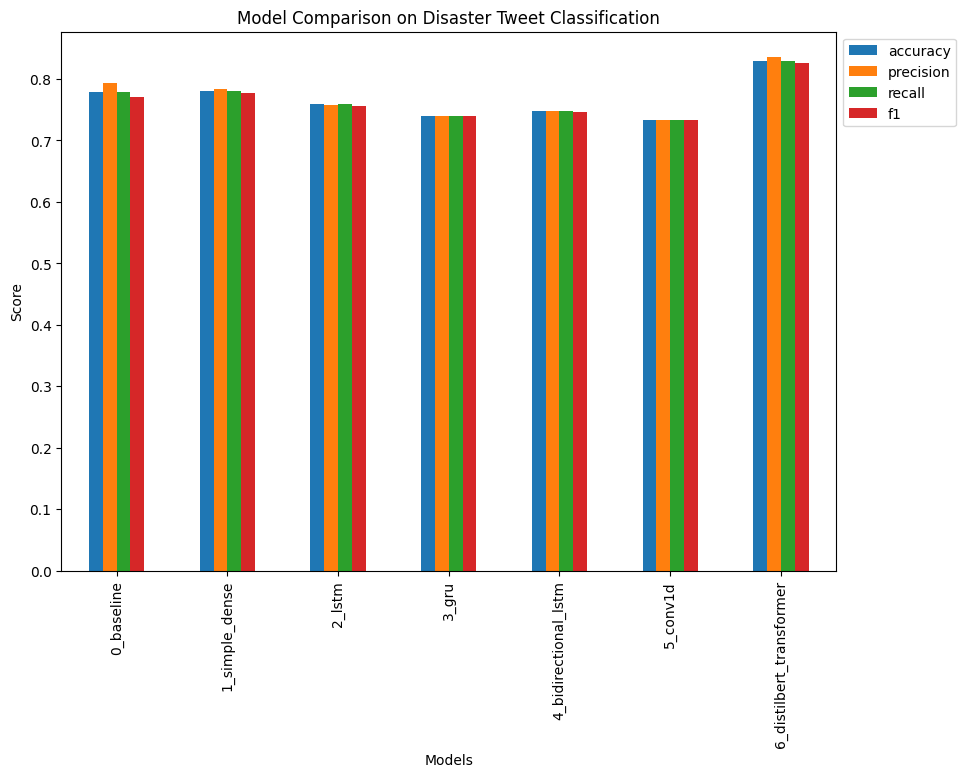

In [60]:
# Reduce the accuracy to same scale as other metrics (0-1)
all_model_results["accuracy"] = all_model_results["accuracy"] / 100

# Plot and compare all of the model results
import matplotlib.pyplot as plt

all_model_results.plot(kind="bar", figsize=(10, 7)).legend(bbox_to_anchor=(1.0, 1.0))
plt.title("Model Comparison on Disaster Tweet Classification")
plt.xlabel("Models")
plt.ylabel("Score")
plt.show()

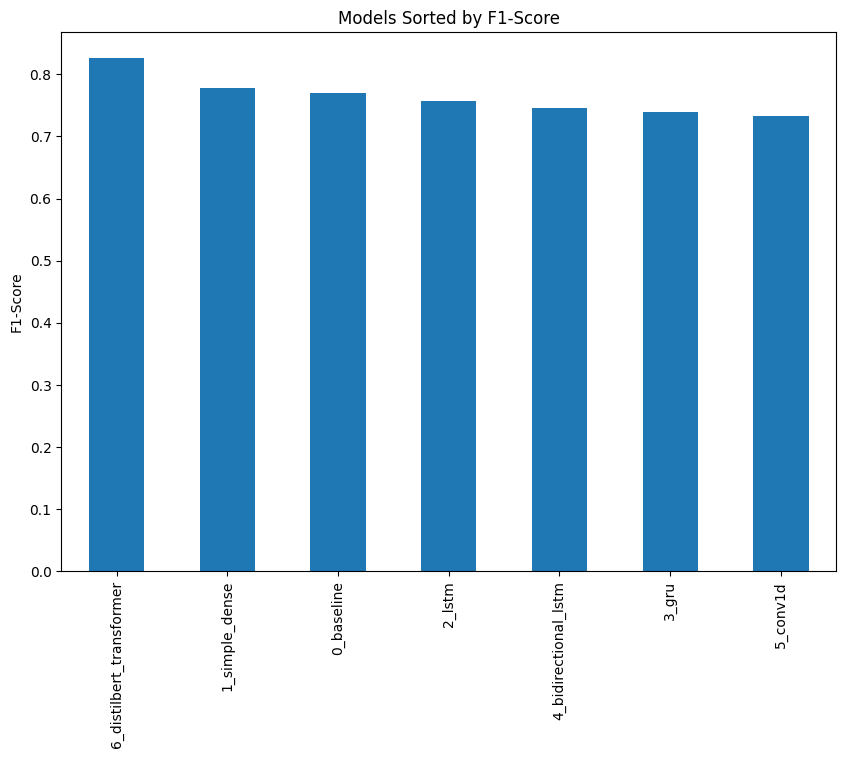

In [61]:
# Sort models by F1-score to find the best performing model
all_model_results.sort_values(by="f1", ascending=False)["f1"].plot(
    kind="bar", figsize=(10, 7)
)
plt.title("Models Sorted by F1-Score")
plt.ylabel("F1-Score")
plt.show()

## Saving and Loading the Best Model

We can save our trained PyTorch model weights using `torch.save` (`.pth` format) to easily reload and verify performance.


In [62]:
# Save Model 6 weights (PyTorch state_dict)
torch.save(model_6.state_dict(), "model_6_DistilBERT.pth")

In [63]:
# Load weights into a new instance to verify performance
loaded_model_6 = DistilBERTClassifier(checkpoint).to(device)
loaded_model_6.load_state_dict(
    torch.load("model_6_DistilBERT.pth", map_location=device)
)
loaded_model_6.eval()

# Evaluate loaded model to confirm performance
loaded_val_preds = []
with torch.no_grad():
    for input_ids, attention_mask, _ in val_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        logits = loaded_model_6(input_ids, attention_mask)
        preds = torch.round(torch.sigmoid(logits))
        loaded_val_preds.extend(preds.cpu().numpy())

loaded_model_6_results = calculate_results(
    y_true=val_df["target"].to_numpy(), y_pred=np.array(loaded_val_preds)
)
loaded_model_6_results == model_6_results

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


True

## Making Predictions on the Test Dataset

Now let's use our best model (Model 6: Pretrained DistilBERT Transformer) to make predictions on the unseen test dataset and display 10 tweets alongside their predicted values.


In [64]:
# Make predictions on test set with Model 6
model_6.eval()
test_pred_probs = []
test_preds = []

with torch.no_grad():
    for input_ids, attention_mask in test_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        logits = model_6(input_ids, attention_mask)
        probs = torch.sigmoid(logits)
        preds = torch.round(probs)

        test_pred_probs.extend(probs.cpu().numpy())
        test_preds.extend(preds.cpu().numpy())

test_pred_probs = np.array(test_pred_probs)
test_preds = np.array(test_preds).astype(int)

In [65]:
# Create a DataFrame to inspect test tweets with their predictions
test_results_df = test_df.copy()
test_results_df["pred_prob"] = test_pred_probs
test_results_df["prediction"] = test_preds
test_results_df["pred_label"] = test_results_df["prediction"].apply(
    lambda x: "Real Disaster (1)" if x == 1 else "Not a Real Disaster (0)"
)

# Display first 10 results showing tweet text followed by its predicted value
for i, row in test_results_df.head(10).iterrows():
    print(f"--- Tweet #{i+1} ---")
    print(f"Tweet: {row['text']}")
    print(f"Prediction: {row['pred_label']}")
    print(f"Confidence (Pred Prob): {row['pred_prob']:.4f}\n")

--- Tweet #1 ---
Tweet: Just happened a terrible car crash
Prediction: Real Disaster (1)
Confidence (Pred Prob): 0.6193

--- Tweet #2 ---
Tweet: Heard about #earthquake is different cities, stay safe everyone.
Prediction: Real Disaster (1)
Confidence (Pred Prob): 0.7928

--- Tweet #3 ---
Tweet: there is a forest fire at spot pond, geese are fleeing across the street, I cannot save them all
Prediction: Real Disaster (1)
Confidence (Pred Prob): 0.7400

--- Tweet #4 ---
Tweet: Apocalypse lighting. #Spokane #wildfires
Prediction: Real Disaster (1)
Confidence (Pred Prob): 0.9827

--- Tweet #5 ---
Tweet: Typhoon Soudelor kills 28 in China and Taiwan
Prediction: Real Disaster (1)
Confidence (Pred Prob): 0.9967

--- Tweet #6 ---
Tweet: We're shaking...It's an earthquake
Prediction: Real Disaster (1)
Confidence (Pred Prob): 0.8557

--- Tweet #7 ---
Tweet: They'd probably still show more life than Arsenal did yesterday, eh? EH?
Prediction: Not a Real Disaster (0)
Confidence (Pred Prob): 0.0344



In [66]:
# Display first 10 test predictions in tabular format
test_results_df.head(10)[["text", "pred_label", "pred_prob"]]

,text,pred_label,pred_prob
0,Just happened a terrible car crash,Real Disaster (1),0.619283
1,"Heard about #earthquake is different cities, s...",Real Disaster (1),0.792793
2,"there is a forest fire at spot pond, geese are...",Real Disaster (1),0.740028
3,Apocalypse lighting. #Spokane #wildfires,Real Disaster (1),0.982731
4,Typhoon Soudelor kills 28 in China and Taiwan,Real Disaster (1),0.996659
5,We're shaking...It's an earthquake,Real Disaster (1),0.855674
6,They'd probably still show more life than Arse...,Not a Real Disaster (0),0.034442
7,Hey! How are you?,Not a Real Disaster (0),0.046202
8,What a nice hat?,Not a Real Disaster (0),0.026690
9,Fuck off!,Not a Real Disaster (0),0.036004
